# EDA  Analysis on the ECG Image Dataset

## PART 1 - EDA on Raw ECG Images


## Count images per category

C:\Users\User\AppData\Local\Temp\ipykernel_14284\2398797084.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


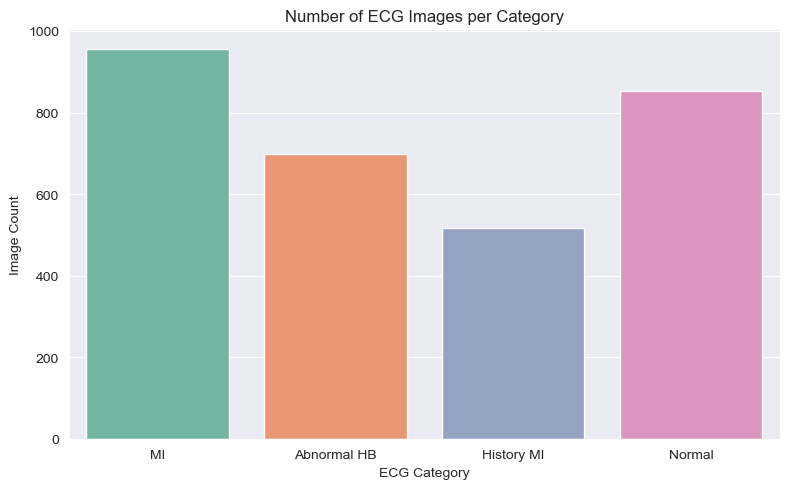

,category_short,count
0,MI,956
1,Abnormal HB,699
2,History MI,516
3,Normal,852


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

RAW_DATASET = Path("C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/ECG_DATA/train")   # <-- YOUR PATH

# ---------------------------------------------
# 1. Count images per category
# ---------------------------------------------
categories = [d for d in RAW_DATASET.iterdir() if d.is_dir()]

data_summary = []

for cat in categories:
    count = len(list(cat.glob("*.jpg"))) + len(list(cat.glob("*.png")))
    data_summary.append([cat.name, count])

df_counts = pd.DataFrame(data_summary, columns=["category", "count"])

# ---------------------------------------------
# 2. Shorten category names (mapping)
# ---------------------------------------------
df_counts["category_short"] = df_counts["category"].replace({
    "Normal Person ECG Images (284x12=3408)": "Normal",
    "ECG Images of Patient that have History of MI (172x12=2064)": "History MI",
    "ECG Images of Myocardial Infarction Patients (240x12=2880)": "MI",
    "ECG Images of Patient that have abnormal heartbeat (233x12=2796)": "Abnormal HB"
})

# ---------------------------------------------
# 3. Plot with short labels
# ---------------------------------------------
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_counts,
    x="category_short",
    y="count",
    palette="Set2"
)

plt.title("Number of ECG Images per Category")
plt.xlabel("ECG Category")
plt.ylabel("Image Count")
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 4. Show summary table
# ---------------------------------------------
df_counts[["category_short", "count"]]



## Image Resolution Analysis

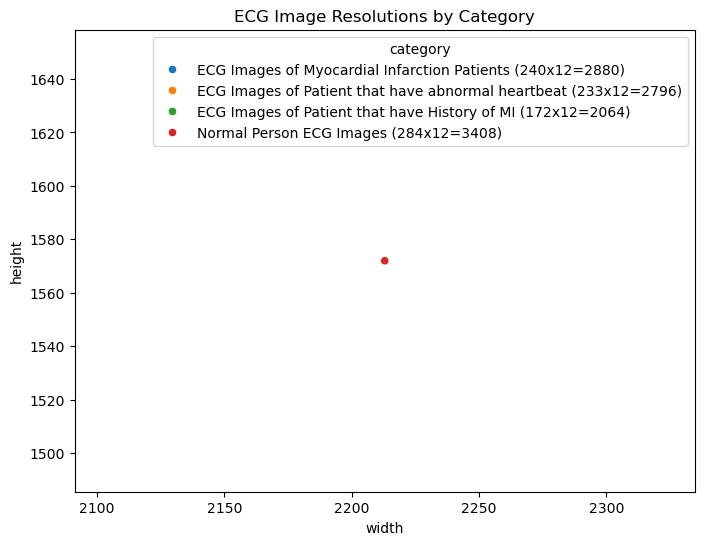

,width,height
count,3023.0,3023.0
mean,2213.0,1572.0
std,0.0,0.0
min,2213.0,1572.0
25%,2213.0,1572.0
50%,2213.0,1572.0
75%,2213.0,1572.0
max,2213.0,1572.0


In [9]:
from PIL import Image
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

resolutions = []

for cat in categories:
    for img_path in cat.glob("*.jpg"):
        try:
            with Image.open(img_path) as im:
                w, h = im.size   # <-- FAST, no full decode
                resolutions.append([cat.name, w, h])
        except:
            print("Skipped corrupted:", img_path)

df_res = pd.DataFrame(resolutions, columns=["category","width","height"])

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_res, x="width", y="height", hue="category")
plt.title("ECG Image Resolutions by Category")
plt.show()

df_res.describe()


## Aspect Ratio Distribution

C:\Users\User\AppData\Local\Temp\ipykernel_14500\2025703166.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ratio_mean, x="category_short", y="aspect_ratio", palette="Set2")


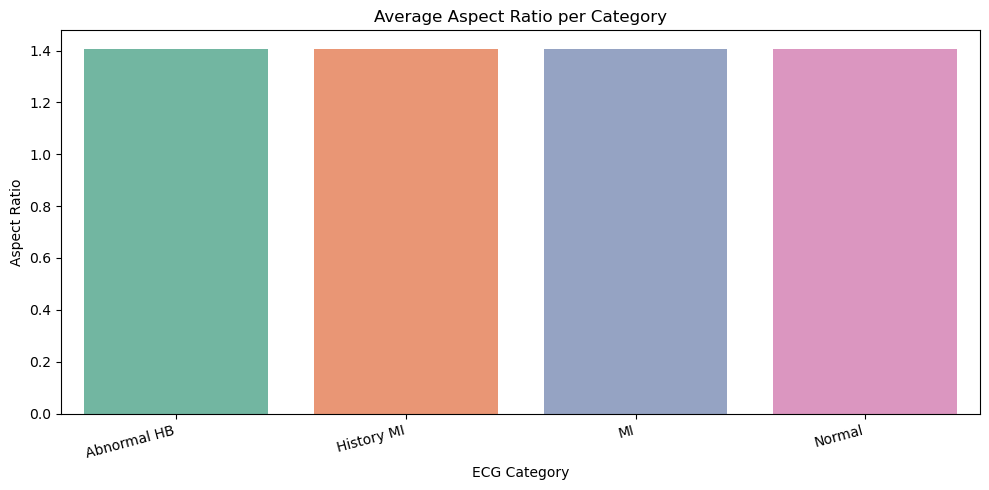

In [11]:
# Compute aspect ratio first
df_res["aspect_ratio"] = df_res["width"] / df_res["height"]

df_res["category_short"] = df_res["category"].replace({
    "Normal Person ECG Images (284x12=3408)": "Normal",
    "ECG Images of Patient that have History of MI (172x12=2064)": "History MI",
    "ECG Images of Myocardial Infarction Patients (240x12=2880)": "MI",
    "ECG Images of Patient that have abnormal heartbeat (233x12=2796)": "Abnormal HB"
})
ratio_mean = df_res.groupby("category_short")["aspect_ratio"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=ratio_mean, x="category_short", y="aspect_ratio", palette="Set2")

plt.title("Average Aspect Ratio per Category")
plt.xlabel("ECG Category")
plt.ylabel("Aspect Ratio")

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## Pixel Intensity Distribution (Brightness)

C:\Users\User\AppData\Local\Temp\ipykernel_14500\3282721198.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bright, y="category_short", x="brightness", palette="Set2")


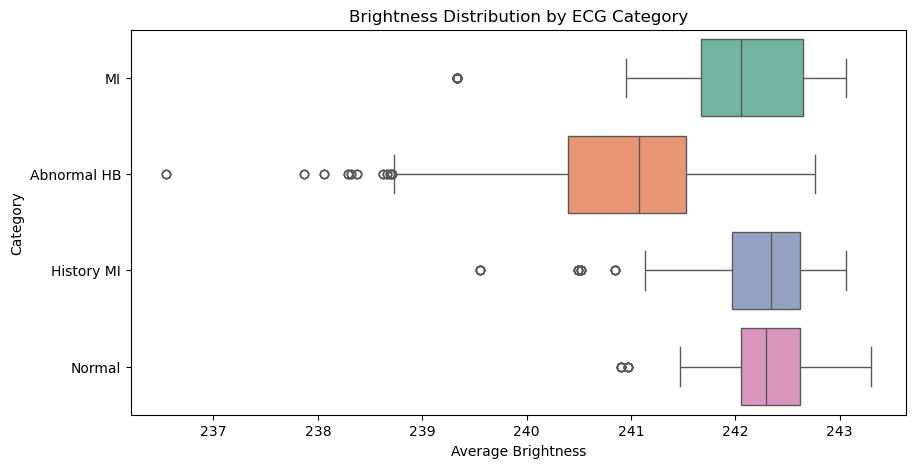

In [12]:
# -------------------------------
# 1. Compute brightness per image
# -------------------------------
brightness = []

for cat in categories:
    for img_path in cat.glob("*.jpg"):
        img = cv2.imread(str(img_path), 0)
        if img is not None:
            brightness.append([cat.name, img.mean()])

df_bright = pd.DataFrame(brightness, columns=["category", "brightness"])

# -------------------------------
# 2. Simplify category names
# -------------------------------
df_bright["category_short"] = df_bright["category"].replace({
    "Normal Person ECG Images (284x12=3408)": "Normal",
    "ECG Images of Patient that have History of MI (172x12=2064)": "History MI",
    "ECG Images of Myocardial Infarction Patients (240x12=2880)": "MI",
    "ECG Images of Patient that have abnormal heartbeat (233x12=2796)": "Abnormal HB"
})

# -------------------------------
# 3. Plot brightness distribution
# -------------------------------
plt.figure(figsize=(10,5))
sns.boxplot(data=df_bright, y="category_short", x="brightness", palette="Set2")
plt.title("Brightness Distribution by ECG Category")
plt.xlabel("Average Brightness")
plt.ylabel("Category")
plt.show()


## Show Random Samples from Each Category

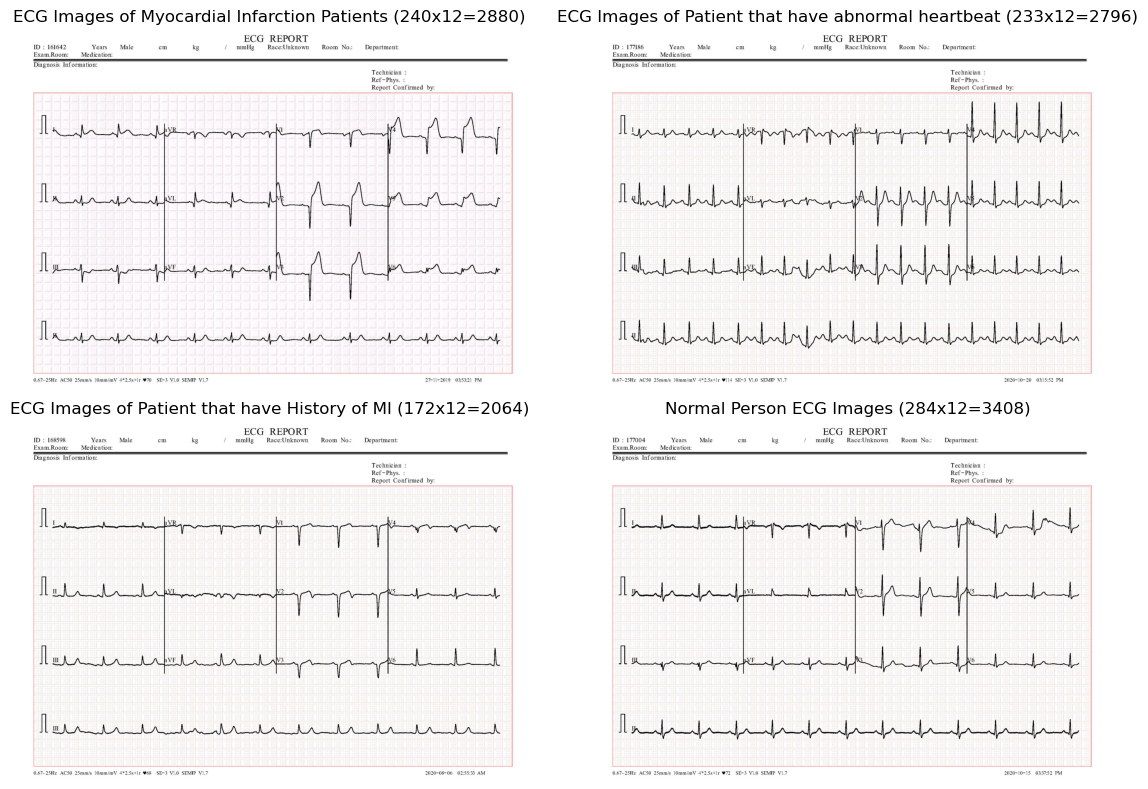

In [17]:
import random

plt.figure(figsize=(12,8))

i = 1
for cat in categories:
    sample_img = random.choice(list(cat.glob("*.jpg")))
    img = cv2.imread(str(sample_img))
    plt.subplot(2,2,i)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(cat.name)
    plt.axis("off")
    i += 1

plt.tight_layout()
plt.show()


# PART 2 — EDA on 12-Lead Flattened CSV Files

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

PATH = Path("C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/ECG_PREPROCESS_OUTPUT")

csv_files = list(PATH.glob("*_flattened.csv"))
csv_files


[WindowsPath('C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/ECG_PREPROCESS_OUTPUT/ECG Images of Myocardial Infarction Patients (240x12=2880)_flattened.csv'),
 WindowsPath('C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/ECG_PREPROCESS_OUTPUT/ECG Images of Patient that have abnormal heartbeat (233x12=2796)_flattened.csv'),
 WindowsPath('C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/ECG_PREPROCESS_OUTPUT/ECG Images of Patient that have History of MI (172x12=2064)_flattened.csv'),
 WindowsPath('C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/ECG_PREPROCESS_OUTPUT/Normal Person ECG Images (284x12=3408)_flattened.csv')]

## Load all four CSVs

In [24]:
all_dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    df["label"] = f.stem.replace("_flattened","")
    all_dfs.append(df)

full_df = pd.concat(all_dfs, axis=0)
full_df.shape


(928, 8846)

## Class Distribution

C:\Users\User\AppData\Local\Temp\ipykernel_14500\845141321.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=full_df, x="label_short", palette="Set2")


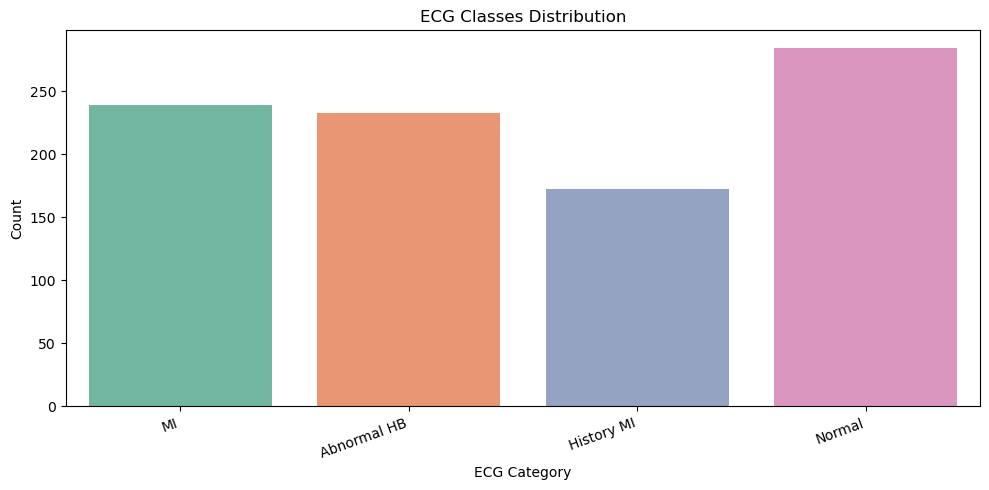

In [26]:
full_df["label_short"] = full_df["label"].replace({
    "Normal Person ECG Images (284x12=3408)": "Normal",
    "ECG Images of Patient that have History of MI (172x12=2064)": "History MI",
    "ECG Images of Myocardial Infarction Patients (240x12=2880)": "MI",
    "ECG Images of Patient that have abnormal heartbeat (233x12=2796)": "Abnormal HB"
})
plt.figure(figsize=(10,5))
sns.countplot(data=full_df, x="label_short", palette="Set2")

plt.title("ECG Classes Distribution")
plt.xlabel("ECG Category")
plt.ylabel("Count")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## . Summary Statistics Per Class

In [ ]:
# Select numeric columns only (all Lead columns)
numeric_cols = full_df.select_dtypes(include=[np.number]).columns

# Now compute mean safely
stats = full_df.groupby("label")[numeric_cols].mean()

stats


,Lead1_0,Lead1_1,Lead1_2,Lead1_3,Lead1_4,Lead1_5,Lead1_6,Lead1_7,Lead1_8,Lead1_9,...,Lead12_727,Lead12_728,Lead12_729,Lead12_730,Lead12_731,Lead12_732,Lead12_733,Lead12_734,Lead12_735,Lead12_736
label,,,,,,,,,,,,,,,,,,,,,
ECG Images of Myocardial Infarction Patients (240x12=2880),0.721032,0.721032,0.721032,0.721032,0.721032,0.721032,0.721032,0.721032,0.721032,0.721032,...,0.247011,0.247011,0.247011,0.247011,0.247011,0.247011,0.247011,0.247011,0.247011,0.247011
ECG Images of Patient that have History of MI (172x12=2064),0.720790,0.720790,0.720790,0.720790,0.720790,0.720790,0.720790,0.720790,0.720790,0.720790,...,0.230379,0.230379,0.230379,0.230379,0.230379,0.230379,0.230379,0.230379,0.230379,0.230379
ECG Images of Patient that have abnormal heartbeat (233x12=2796),0.721315,0.721315,0.721315,0.721315,0.721315,0.721315,0.721315,0.721315,0.721315,0.721315,...,0.251231,0.251231,0.251231,0.251231,0.251231,0.251231,0.251231,0.251231,0.251231,0.251231
Normal Person ECG Images (284x12=3408),0.723375,0.723375,0.723375,0.723375,0.723375,0.723375,0.723375,0.723375,0.723375,0.723375,...,0.228261,0.228261,0.228261,0.228261,0.228261,0.228261,0.228261,0.228261,0.228261,0.228261


## Correlation Heatmap (First 120 Features Only for Speed)

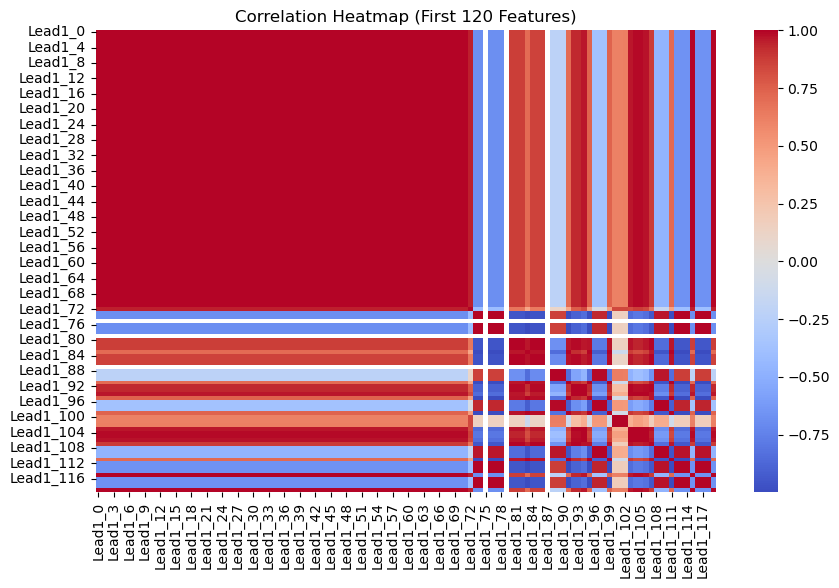

In [27]:
subset = full_df.iloc[:,1:121]  # avoid filename column
plt.figure(figsize=(10,6))
sns.heatmap(subset.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap (First 120 Features)")
plt.show()


## PCA Visualization (Reducing 8844 Features → 2D)

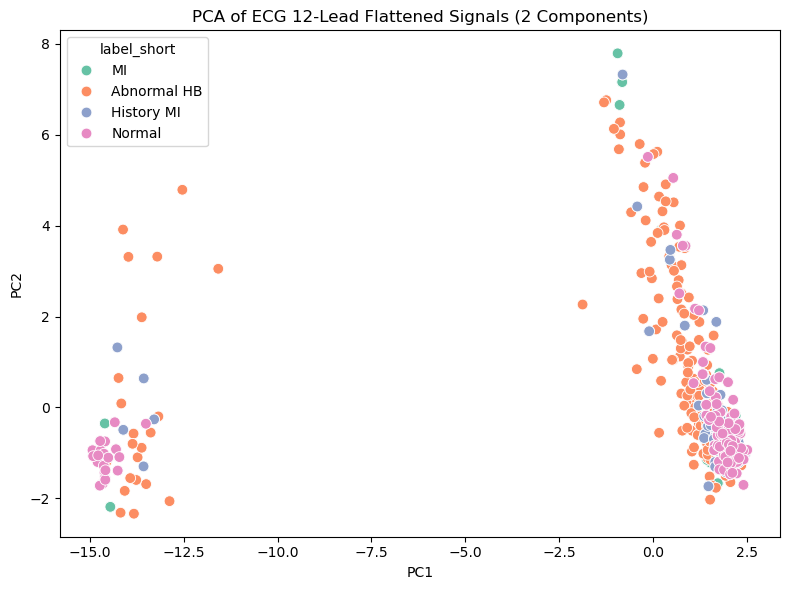

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Only numeric columns
X = full_df.drop(columns=["filename", "label", "label_short"], errors='ignore')
y = full_df["label_short"]

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="Set2", s=60)

plt.title("PCA of ECG 12-Lead Flattened Signals (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


## Compare Signals Between Categories

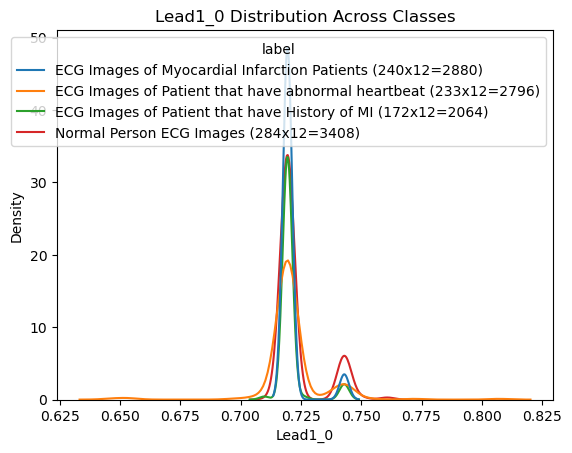

In [29]:
sns.kdeplot(data=full_df, x="Lead1_0", hue="label")
plt.title("Lead1_0 Distribution Across Classes")
plt.show()
